In [1]:
!pip install pandas numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv("pizza_sales.csv")

In [4]:
df

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01-01-2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01-01-2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
...,...,...,...,...,...,...,...,...,...,...,...,...
48615,48616,21348,ckn_alfredo_m,1,31-12-2015,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,31-12-2015,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,31-12-2015,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,31-12-2015,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [5]:
df.head()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza
3,4,2,ital_supr_l,1,01-01-2015,11:57:40,20.75,20.75,L,Supreme,"Calabrese Salami, Capocollo, Tomatoes, Red Oni...",The Italian Supreme Pizza
4,5,2,mexicana_m,1,01-01-2015,11:57:40,16.00,16.00,M,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza


In [6]:
df.tail()

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
48615,48616,21348,ckn_alfredo_m,1,31-12-2015,21:23:10,16.75,16.75,M,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A...",The Chicken Alfredo Pizza
48616,48617,21348,four_cheese_l,1,31-12-2015,21:23:10,17.95,17.95,L,Veggie,"Ricotta Cheese, Gorgonzola Piccante Cheese, Mo...",The Four Cheese Pizza
48617,48618,21348,napolitana_s,1,31-12-2015,21:23:10,12.00,12.00,S,Classic,"Tomatoes, Anchovies, Green Olives, Red Onions,...",The Napolitana Pizza
48618,48619,21349,mexicana_l,1,31-12-2015,22:09:54,20.25,20.25,L,Veggie,"Tomatoes, Red Peppers, Jalapeno Peppers, Red O...",The Mexicana Pizza
48619,48620,21350,bbq_ckn_s,1,31-12-2015,23:02:05,12.75,12.75,S,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,...",The Barbecue Chicken Pizza


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48620 entries, 0 to 48619
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   pizza_id           48620 non-null  int64  
 1   order_id           48620 non-null  int64  
 2   pizza_name_id      48620 non-null  object 
 3   quantity           48620 non-null  int64  
 4   order_date         48620 non-null  object 
 5   order_time         48620 non-null  object 
 6   unit_price         48620 non-null  float64
 7   total_price        48620 non-null  float64
 8   pizza_size         48620 non-null  object 
 9   pizza_category     48620 non-null  object 
 10  pizza_ingredients  48620 non-null  object 
 11  pizza_name         48620 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 4.5+ MB


In [8]:
df.shape

(48620, 12)

In [9]:
# Convert order_date to datetime format
df['order_date'] = pd.to_datetime(df['order_date'], format= '%d-%m-%Y')


In [10]:
#KPI
total_revenue = df['total_price'].sum()
total_orders = df['order_id'].nunique()
total_pizzas_sold = df['quantity'].sum()
average_order_value = total_revenue / total_orders
average_pizzas_per_order = total_pizzas_sold / total_orders

In [11]:
# Store KPI results
kpi_results = {
    "Total Revenue": total_revenue,
    "Total Orders": total_orders,
    "Total Pizzas Sold": total_pizzas_sold,
    "Average Order Value": average_order_value,
    "Average Pizzas per Order": average_pizzas_per_order,
}

In [12]:
kpi_results

{'Total Revenue': np.float64(817860.0499999999),
 'Total Orders': 21350,
 'Total Pizzas Sold': np.int64(49574),
 'Average Order Value': np.float64(38.30726229508196),
 'Average Pizzas per Order': np.float64(2.321967213114754)}

In [13]:
df['day_week']=df['order_date'].dt.day_name()

In [14]:
df['day_week']

0        Thursday
1        Thursday
2        Thursday
3        Thursday
4        Thursday
           ...   
48615    Thursday
48616    Thursday
48617    Thursday
48618    Thursday
48619    Thursday
Name: day_week, Length: 48620, dtype: object

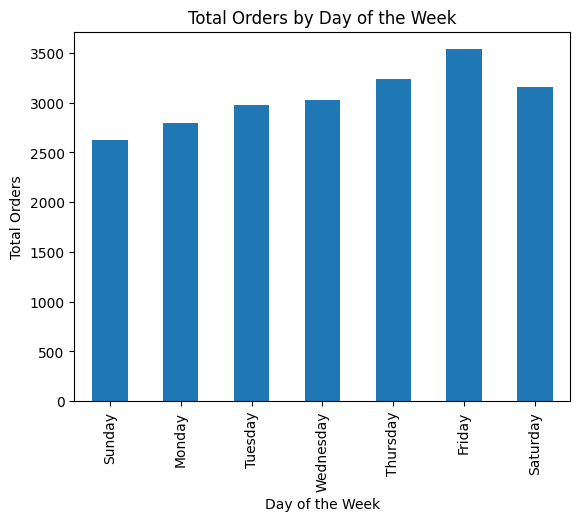

In [15]:
#1.DAILY TREND FOR TOTAL ORDERS:
daily_orders = df.groupby('day_week')['order_id'].nunique()
order_of_days = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
daily_orders = daily_orders.reindex(order_of_days)
plt.figure()
daily_orders.plot(kind='bar')
plt.xlabel("Day of the Week")
plt.ylabel("Total Orders")
plt.title("Total Orders by Day of the Week")

plt.show()

In [16]:
df['month_name'] = df['order_date'].dt.month_name()

In [17]:
df['month_name']

0         January
1         January
2         January
3         January
4         January
           ...   
48615    December
48616    December
48617    December
48618    December
48619    December
Name: month_name, Length: 48620, dtype: object

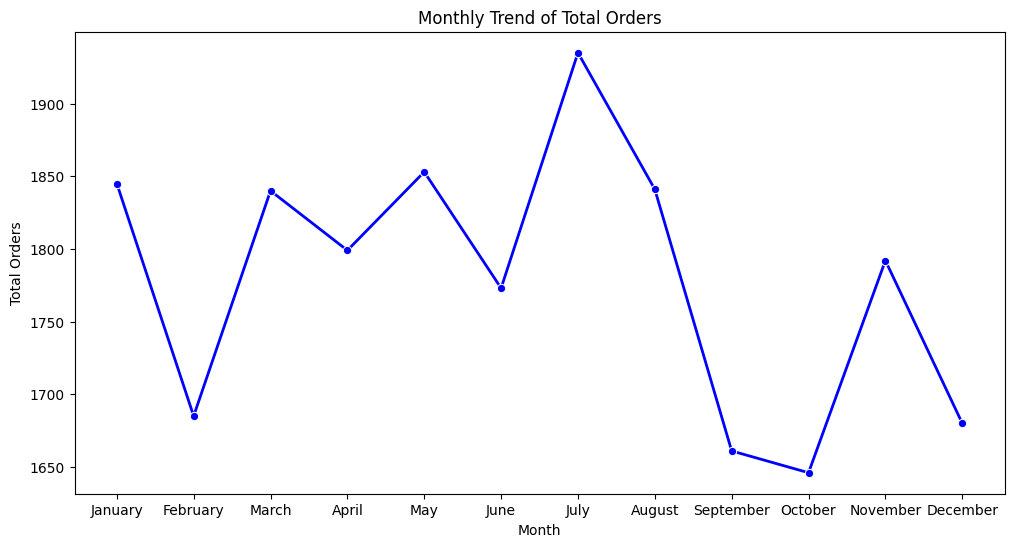

In [18]:
#2.MONTHLY TREND FOR TOTAL ORDERS:
monthly_orders = df.groupby('month_name')['order_id'].nunique()

# Define correct order of months
order_of_months = ["January", "February", "March", "April", "May", "June", 
                    "July", "August", "September", "October", "November", "December"]
monthly_orders = monthly_orders.reindex(order_of_months)

plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_orders.index, y=monthly_orders.values, marker="o", color='blue', linewidth=2)
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.title("Monthly Trend of Total Orders")
plt.show()

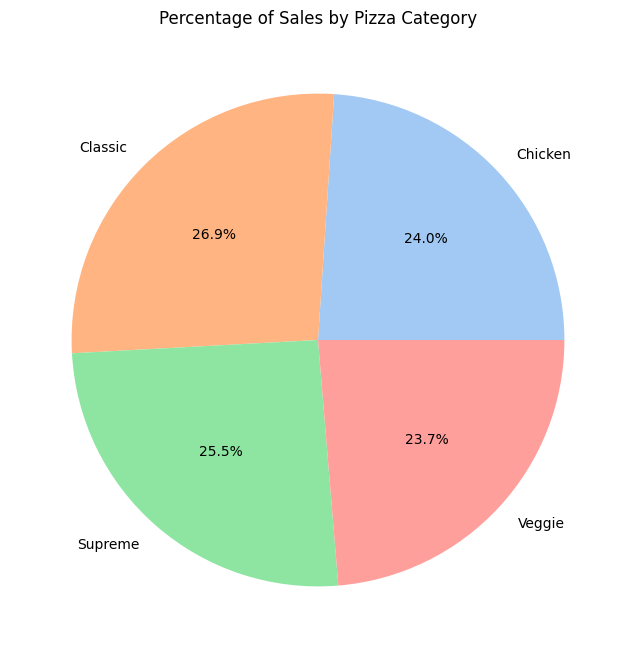

In [19]:
# 3.PERCENTAGE OF SALES BY PIZZA CATEGORY:
category_sales = df.groupby('pizza_category')['total_price'].sum()

# Plot pie chart for sales by pizza category
plt.figure(figsize=(8, 8))
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title("Percentage of Sales by Pizza Category")
plt.show()

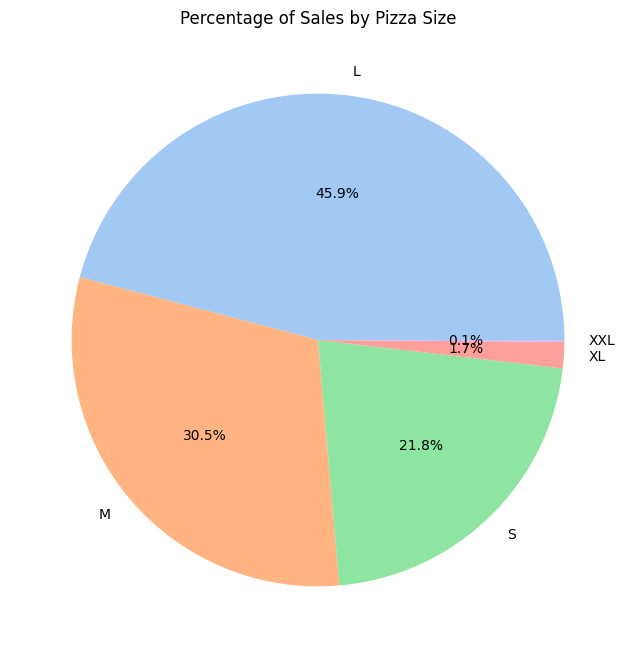

In [20]:
# 4.PERCENTAGE OF SALES BY PIZZA SIZE:
size_sales = df.groupby('pizza_size')['total_price'].sum()

# Plot pie chart for sales by pizza size
plt.figure(figsize=(8, 8))
plt.pie(size_sales, labels=size_sales.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title("Percentage of Sales by Pizza Size")
plt.show()

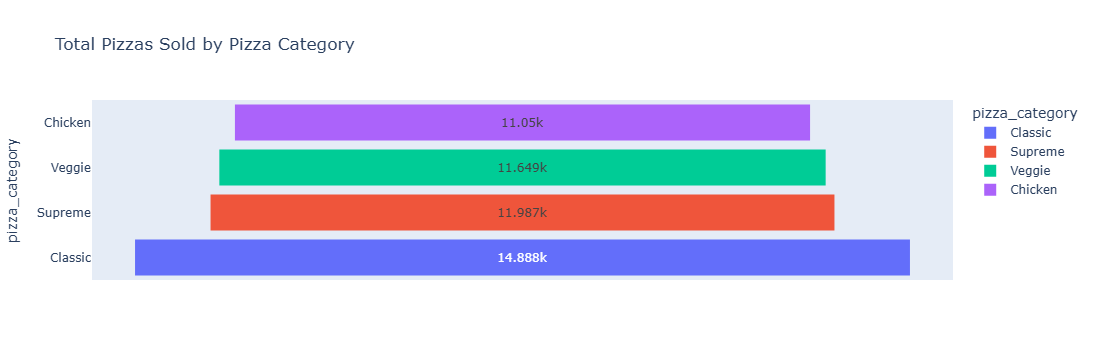

<Figure size 640x480 with 0 Axes>

In [21]:
#5.TOTAL PIZZA SOLD BY PIZZA CATEGORY:
# Option 1: Rename variable to category_sales
category_sales = df.groupby('pizza_category')['quantity'].sum().reset_index()

import plotly.express as px
fig = px.funnel(
    category_sales.sort_values(by='quantity', ascending=False),
    x='quantity',
    y='pizza_category',
    color='pizza_category',
    title='Total Pizzas Sold by Pizza Category'
)
plt.figure()
fig.show()

C:\Users\prana\AppData\Local\Temp\ipykernel_8044\988187202.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\prana\AppData\Local\Temp\ipykernel_8044\988187202.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\prana\AppData\Local\Temp\ipykernel_8044\988187202.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




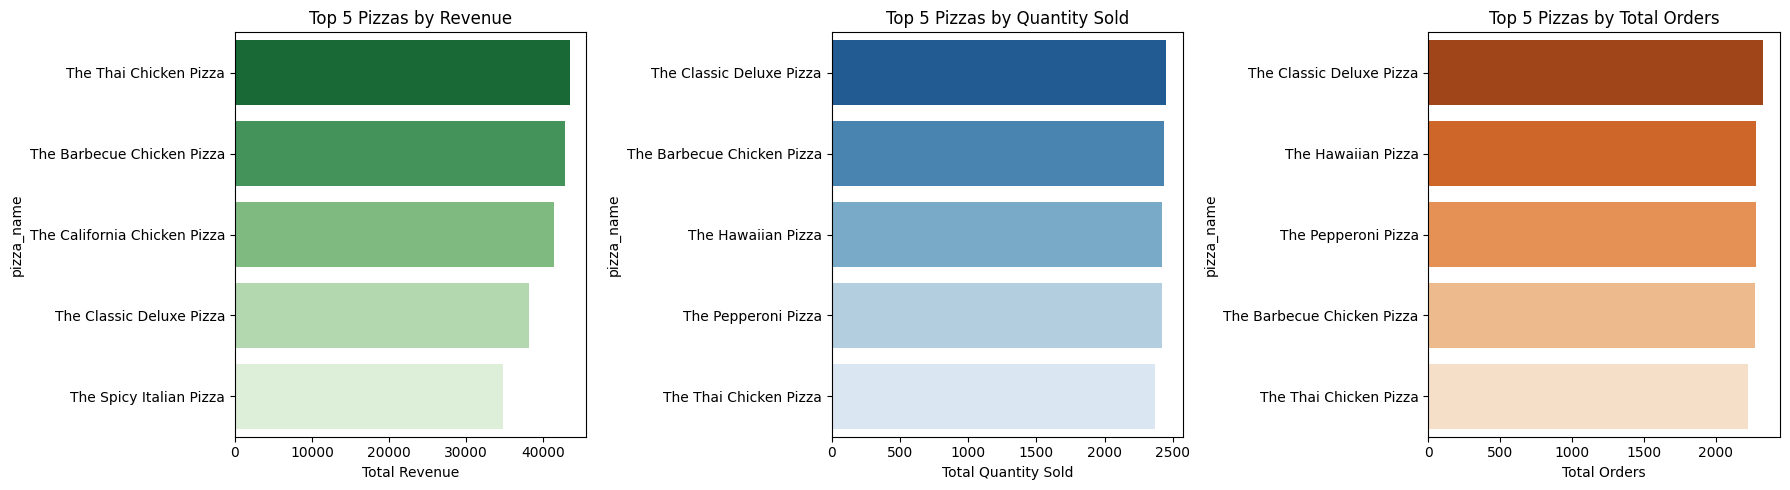

In [22]:
#6.TOP 5 BEST SELLERS BY REVENUE,TOTAL QUANTITY AND TOTAL ORDERS:
# Aggregate data for best-selling pizzas
top_pizzas_revenue = df.groupby('pizza_name')['total_price'].sum().nlargest(5)
top_pizzas_quantity = df.groupby('pizza_name')['quantity'].sum().nlargest(5)
top_pizzas_orders = df.groupby('pizza_name')['order_id'].nunique().nlargest(5)

# Plot best-selling pizzas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(y=top_pizzas_revenue.index, x=top_pizzas_revenue.values, ax=axes[0], palette="Greens_r")
axes[0].set_title("Top 5 Pizzas by Revenue")
axes[0].set_xlabel("Total Revenue")

sns.barplot(y=top_pizzas_quantity.index, x=top_pizzas_quantity.values, ax=axes[1], palette="Blues_r")
axes[1].set_title("Top 5 Pizzas by Quantity Sold")
axes[1].set_xlabel("Total Quantity Sold")

sns.barplot(y=top_pizzas_orders.index, x=top_pizzas_orders.values, ax=axes[2], palette="Oranges_r")
axes[2].set_title("Top 5 Pizzas by Total Orders")
axes[2].set_xlabel("Total Orders")

plt.tight_layout()
plt.show()

C:\Users\prana\AppData\Local\Temp\ipykernel_8044\750806692.py:10: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\prana\AppData\Local\Temp\ipykernel_8044\750806692.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\prana\AppData\Local\Temp\ipykernel_8044\750806692.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




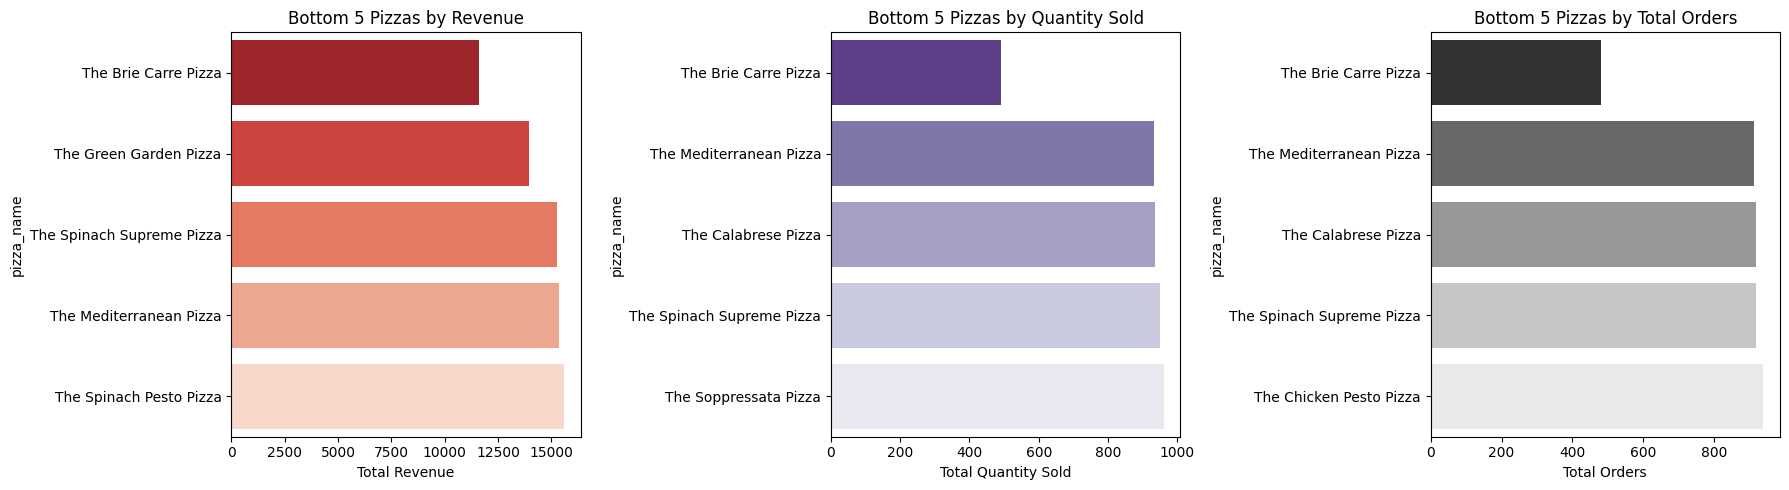

In [23]:
#7.BOTTOM 5 BEST SELLERS BY REVENUE,TOTAL QUANTITY AND TOTAL ORDERS:
# Aggregate data for worst-selling pizzas
bottom_pizzas_revenue = df.groupby('pizza_name')['total_price'].sum().nsmallest(5)
bottom_pizzas_quantity = df.groupby('pizza_name')['quantity'].sum().nsmallest(5)
bottom_pizzas_orders = df.groupby('pizza_name')['order_id'].nunique().nsmallest(5)

# Plot worst-selling pizzas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(y=bottom_pizzas_revenue.index, x=bottom_pizzas_revenue.values, ax=axes[0], palette="Reds_r")
axes[0].set_title("Bottom 5 Pizzas by Revenue")
axes[0].set_xlabel("Total Revenue")

sns.barplot(y=bottom_pizzas_quantity.index, x=bottom_pizzas_quantity.values, ax=axes[1], palette="Purples_r")
axes[1].set_title("Bottom 5 Pizzas by Quantity Sold")
axes[1].set_xlabel("Total Quantity Sold")

sns.barplot(y=bottom_pizzas_orders.index, x=bottom_pizzas_orders.values, ax=axes[2], palette="Greys_r")
axes[2].set_title("Bottom 5 Pizzas by Total Orders")
axes[2].set_xlabel("Total Orders")

plt.tight_layout()
plt.show()